# Практика: Наивный Байес с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите датасет для задачи классификации;
2. подготовите данные для обучения;
3. реализуете **Гауссовский Наивный Байес с нуля**:
   - оценку априорных вероятностей классов,
   - оценку параметров (среднее и дисперсия) по каждому признаку,
   - вычисление правдоподобия (likelihood),
   - классификацию по правилу Байеса;
4. обучите свою модель;
5. сравните её качество и параметры с реализацией из `scikit-learn`;
6. проверите, что происходит при нарушении допущения о независимости признаков.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Iris` из `sklearn.datasets`:
- задача **многоклассовой классификации** (3 класса);
- признаки числовые, непрерывные;
- датасет хорошо подходит для изучения Гауссовского Наивного Байеса.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - в чём главное допущение Наивного Байеса и когда оно нарушается;
   - когда Наивный Байес предпочтительнее логистической регрессии.

## Коротко о теории

### 1. Теорема Байеса
Для классификации нам нужно найти наиболее вероятный класс \(c\) при данных признаках \(x\):

\[
P(c \mid x) = \frac{P(x \mid c) \cdot P(c)}{P(x)}
\]

Так как \(P(x)\) одинаково для всех классов, достаточно максимизировать числитель:

\[
\hat{c} = \arg\max_{c} \; P(x \mid c) \cdot P(c)
\]

### 2. Наивное допущение о независимости
«Наивным» Байес называется потому, что предполагает условную **независимость** признаков:

\[
P(x \mid c) = \prod_{j=1}^{d} P(x_j \mid c)
\]

Это сильное допущение, которое редко выполняется на практике, но модель всё равно часто работает хорошо.

### 3. Гауссовское допущение
Для непрерывных признаков предполагаем, что каждый признак имеет нормальное распределение внутри класса:

\[
P(x_j \mid c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}} \exp\!\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)
\]

### 4. Логарифм для численной стабильности
Произведение многих вероятностей быстро стремится к нулю. На практике считаем **логарифм**:

\[
\log P(c \mid x) \propto \log P(c) + \sum_{j=1}^{d} \log P(x_j \mid c)
\]

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.naive_bayes.GaussianNB`:
- accuracy,
- precision (macro),
- recall (macro),
- f1 (macro).

### 6. Априорные вероятности
Оцениваются по частоте встречаемости каждого класса в обучающей выборке:

\[
P(c) = \frac{n_c}{n}
\]

In [502]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [503]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Классы:", data.target_names)
display(X.head())
display(y.value_counts().rename(index=dict(enumerate(data.target_names))))

Размер X: (150, 4)
Классы: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,count
target,
setosa,50
versicolor,50
virginica,50


Пропуски по признакам:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0



Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


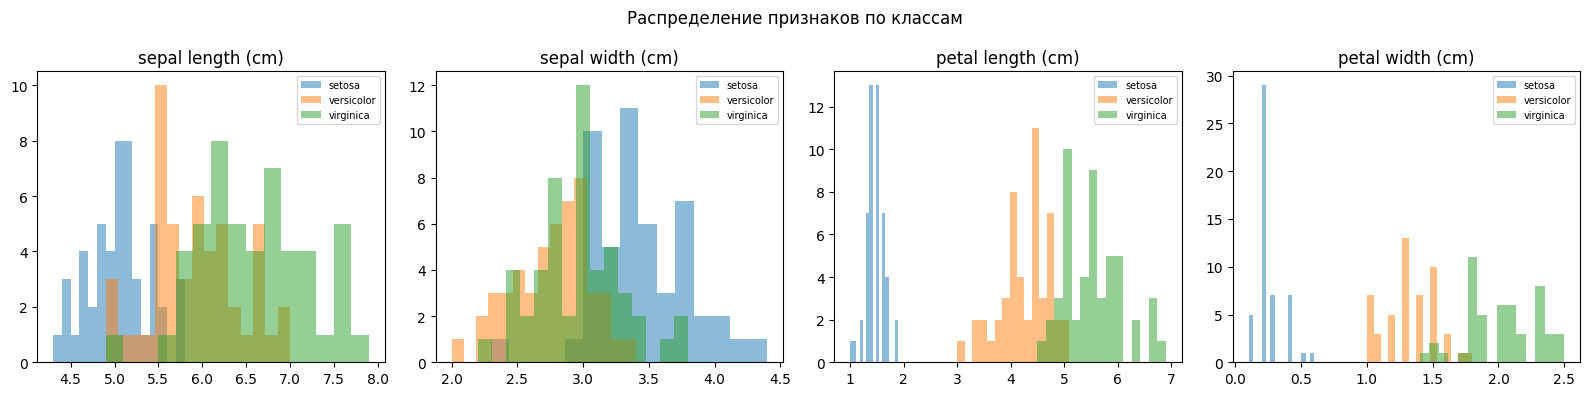

In [504]:
print("Пропуски по признакам:")
display(X.isna().sum())

print("\nБазовая статистика:")
display(X.describe().T)

# Визуализируем распределение одного признака по классам
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(X.columns):
    for cls in range(3):
        axes[i].hist(X[col][y == cls], alpha=0.5, label=data.target_names[cls], bins=15)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
plt.suptitle("Распределение признаков по классам")
plt.tight_layout()
plt.show()

## Шаг 1. Разделение данных

Ниже нужно:
1. разбить выборку на train и test;
2. получить `X_train`, `X_test`, `y_train`, `y_test`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`.
- **Стандартизация здесь не нужна** — Наивный Байес сам оценивает параметры распределения по каждому признаку.

In [505]:
# YOUR CODE HERE
# Разбейте данные на train/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y, shuffle = True)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Распределение классов в train:", pd.Series(y_train).value_counts().to_dict())

Train shape: (120, 4)
Test shape: (30, 4)
Распределение классов в train: {0: 40, 2: 40, 1: 40}


## Шаг 2. Оцениваем априорные вероятности классов

Напишите функцию `compute_priors(y)`, которая возвращает словарь `{класс: P(класс)}`.

Проверка:
- сумма всех вероятностей должна быть равна `1.0`.

In [506]:
def compute_priors(y):
    """
    Вычисляет априорные вероятности каждого класса.
    Возвращает словарь {класс: вероятность}.
    """
    priors = {}
    n = len(y)
    for c in np.unique(y):
        priors[c] = np.sum(y == c) / n
    return priors

priors = compute_priors(y_train.values)
print("Априорные вероятности:", priors)
print("Сумма:", sum(priors.values()))

Априорные вероятности: {np.int64(0): np.float64(0.3333333333333333), np.int64(1): np.float64(0.3333333333333333), np.int64(2): np.float64(0.3333333333333333)}
Сумма: 1.0


## Шаг 3. Оцениваем параметры распределений по каждому классу

Для Гауссовского Наивного Байеса нужно по каждому классу и каждому признаку оценить:
- **среднее** `mu[c, j]` — среднее значение признака \(j\) в классе \(c\),
- **дисперсию** `var[c, j]` — дисперсию признака \(j\) в классе \(c\).

Напишите функцию `fit_gaussian_params(X, y)`, которая возвращает два массива: `means` и `variances` формы `(n_classes, n_features)`.

Подсказка:
- используйте `np.var(...)` — это **несмещённую** дисперсию лучше считать с `ddof=0` (по умолчанию).

In [507]:
def fit_gaussian_params(X, y):
    """
    Оценивает mu и var для каждого (класс, признак).
    X: np.array (n_samples, n_features)
    y: np.array (n_samples,)
    Возвращает: means (n_classes, n_features), variances (n_classes, n_features)
    """
    classes = np.unique(y)
    n_classes = len(classes)
    n_features = X.shape[1]

    means = np.zeros((n_classes, n_features))
    variances = np.zeros((n_classes, n_features))

    for i, c in enumerate(classes):
        # YOUR CODE HERE
        # выберите строки X, где y == c
        # посчитайте среднее и дисперсию по каждому признаку
        X_c = X[y == c]
        means[i] = np.mean(X_c, axis=0)
        variances[i] = np.var(X_c, axis=0)

    return means, variances


X_train_np = X_train.values
y_train_np = y_train.values

means, variances = fit_gaussian_params(X_train_np, y_train_np)
print("means shape:", means.shape)
print("\nМатрица средних (класс x признак):")
display(pd.DataFrame(means, columns=data.feature_names, index=data.target_names).round(3))
print("\nМатрица дисперсий (класс x признак):")
display(pd.DataFrame(variances, columns=data.feature_names, index=data.target_names).round(4))

means shape: (3, 4)

Матрица средних (класс x признак):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.477,0.255
versicolor,5.930,2.750,4.252,1.320
virginica,6.610,2.980,5.580,2.040



Матрица дисперсий (класс x признак):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.0928,0.1553,0.0252,0.0130
versicolor,0.2216,0.0930,0.1915,0.0341
virginica,0.4574,0.1221,0.3236,0.0704


## Шаг 4. Вычисляем log-likelihood

Напишите функцию `gaussian_log_likelihood(x, mean, var)`, которая возвращает логарифм плотности нормального распределения:

\[
\log P(x_j \mid c) = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{(x_j - \mu)^2}{2\sigma^2}
\]

Подсказка:
- `var` может быть очень маленьким — добавьте небольшую константу `eps=1e-9` к дисперсии во избежание деления на ноль.

In [508]:
from math import e
def gaussian_log_likelihood(x, mean, var, eps=1e-9):
    """
    Считает log P(x | mu, sigma^2) по нормальному распределению.
    x, mean, var: np.array одинаковой формы (n_features,)
    Возвращает: сумму log-вероятностей по всем признакам (скаляр).
    """
    # защита от деления на ноль
    var = var + eps
    log_likelihood = -0.5 * np.sum(np.log(2 * np.pi * var) + (np.square((x - mean))) / var)
    return log_likelihood


# Проверка: для одного объекта, одного класса
test_x = X_train_np[0]
ll = gaussian_log_likelihood(test_x, means[0], variances[0])
print("Log-likelihood для первого объекта (класс 0):", ll)

Log-likelihood для первого объекта (класс 0): -0.47769884377699867


## Шаг 5. Собираем классификатор в класс

Допишите методы:
- `fit` — оценить прайоры, средние и дисперсии;
- `predict_log_proba` — вычислить логарифм апостериорной вероятности для каждого класса;
- `predict` — вернуть класс с наибольшей апостериорной вероятностью.

Требования:
- использовать логарифмы для численной стабильности;
- метод должен работать на `numpy`-массивах.

In [509]:
class MyGaussianNB:
    def __init__(self):
        self.classes_ = None
        self.log_priors_ = None  # логарифмы априорных вероятностей
        self.means_ = None       # (n_classes, n_features)
        self.variances_ = None   # (n_classes, n_features)

    def fit(self, X, y):
        """
        Оцениваем все параметры по обучающей выборке.
        """
        # YOUR CODE HERE
        # 1) сохраните уникальные классы в self.classes_
        # 2) вычислите log-прайоры
        # 3) вычислите средние и дисперсии через fit_gaussian_params
        self.classes_ = np.unique(y)
        priors = compute_priors(y)
        self.log_priors_ = np.log([priors[c] for c in self.classes_])
        self.means_, self.variances_ = fit_gaussian_params(X, y)
        return self

    def predict_log_proba(self, X):
        """
        Для каждого объекта и каждого класса вычисляет
        log P(c) + sum_j log P(x_j | c).
        Возвращает массив (n_samples, n_classes).
        """

        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        log_proba = np.zeros((n_samples, n_classes))

        for i, cls in enumerate(self.classes_):
            mean = self.means_[i]
            var = self.variances_[i]
            log_prior = self.log_priors_[cls]
            for j in range(n_samples):
                log_likelihood = gaussian_log_likelihood(X[j], mean, var)
                log_proba[j, i] = log_prior + log_likelihood
        return log_proba

    def predict(self, X):
        """
        Возвращает предсказанный класс для каждого объекта.
        """
        # YOUR CODE HERE
        log_proba = self.predict_log_proba(X)
        preds = self.classes_[np.argmax(log_proba, axis=1)]
        return preds

## Шаг 6. Обучаем свою модель

Обучите `MyGaussianNB` и убедитесь, что:
- модель обучилась без ошибок;
- параметры имеют ожидаемую форму.

In [510]:
my_model = MyGaussianNB()

# YOUR CODE HERE
# обучите модель на X_train_np и y_train_np
my_model.fit(X_train_np, y_train_np)

print("Классы:", my_model.classes_)
print("Log-прайоры:", my_model.log_priors_)
print("Форма means_:", my_model.means_.shape)

Классы: [0 1 2]
Log-прайоры: [-1.09861229 -1.09861229 -1.09861229]
Форма means_: (3, 4)


## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте метрики на тестовой выборке:
- accuracy,
- precision (macro),
- recall (macro),
- f1 (macro).

In [511]:
X_test_np = X_test.values
y_test_np = y_test.values

# YOUR CODE HERE
my_pred_test = my_model.predict(X_test_np)

my_metrics = {
    "accuracy": accuracy_score(y_test_np, my_pred_test),
    "precision_macro": precision_score(y_test_np, my_pred_test, average = "macro"),
    "recall_macro": recall_score(y_test_np, my_pred_test, average = "macro"),
    "f1_macro": f1_score(y_test_np, my_pred_test, average = "macro"),
}

pd.Series(my_metrics).round(4)

,0
accuracy,0.9667
precision_macro,0.9697
recall_macro,0.9667
f1_macro,0.9666


## Шаг 8. Confusion matrix

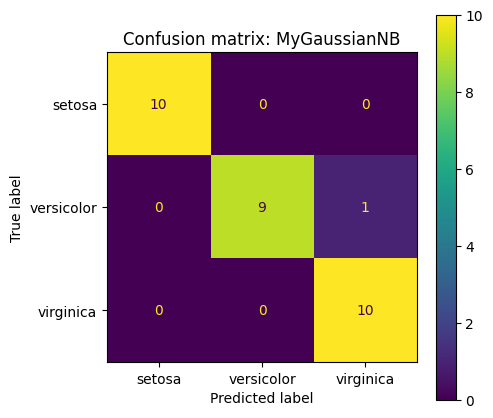

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [512]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_np, my_pred_test,
    display_labels=data.target_names,
    ax=ax
)
plt.title("Confusion matrix: MyGaussianNB")
plt.show()

print(classification_report(y_test_np, my_pred_test, target_names=data.target_names))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечный `GaussianNB` и сравните его с вашей реализацией.

Рекомендации:
- используйте `GaussianNB()` без дополнительных параметров;
- обучайте на тех же данных `X_train_np`.

In [513]:
sk_model = GaussianNB()

# YOUR CODE HERE
# 1) обучите sk_model
# 2) получите предсказания на test
# 3) посчитайте те же метрики
sk_model.fit(X_train_np, y_train_np)
sk_pred_test = sk_model.predict(X_test_np)

sk_metrics = {
    "accuracy": accuracy_score(y_test_np, sk_pred_test),
    "precision_macro": precision_score(y_test_np, sk_pred_test, average = "macro"),
    "recall_macro": recall_score(y_test_np, sk_pred_test, average = "macro"),
    "f1_macro": f1_score(y_test_np, sk_pred_test, average = "macro"),
}

pd.Series(sk_metrics).round(4)

,0
accuracy,0.9667
precision_macro,0.9697
recall_macro,0.9667
f1_macro,0.9666


## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Также сравните оценённые параметры (средние) между реализациями.

Подумайте:
- почему результаты совпадают или отличаются;
- есть ли разница в том, как `sklearn` обрабатывает дисперсию (подсказка: посмотрите параметр `var_smoothing`).

In [514]:
comparison = pd.DataFrame(
    [my_metrics, sk_metrics],
    index=["my_model", "sklearn"]
)
display(comparison.round(4))

# Сравниваем оценённые средние
print("\nСредние MyGaussianNB:")
display(pd.DataFrame(my_model.means_, columns=data.feature_names, index=data.target_names).round(4))

print("\nСредние sklearn GaussianNB:")
display(pd.DataFrame(sk_model.theta_, columns=data.feature_names, index=data.target_names).round(4))

,accuracy,precision_macro,recall_macro,f1_macro
my_model,0.9667,0.9697,0.9667,0.9666
sklearn,0.9667,0.9697,0.9667,0.9666



Средние MyGaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.4775,0.255
versicolor,5.930,2.750,4.2525,1.320
virginica,6.610,2.980,5.5800,2.040



Средние sklearn GaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.4775,0.255
versicolor,5.930,2.750,4.2525,1.320
virginica,6.610,2.980,5.5800,2.040


## Шаг 11. Проверяем допущение о независимости

Наивный Байес предполагает, что признаки **условно независимы** при данном классе.
Проверим, насколько это выполняется: вычислим корреляции между признаками внутри каждого класса.

Подумайте:
- какие пары признаков наиболее скоррелированы;
- нарушает ли это допущение о независимости;
- как это влияет на качество модели.

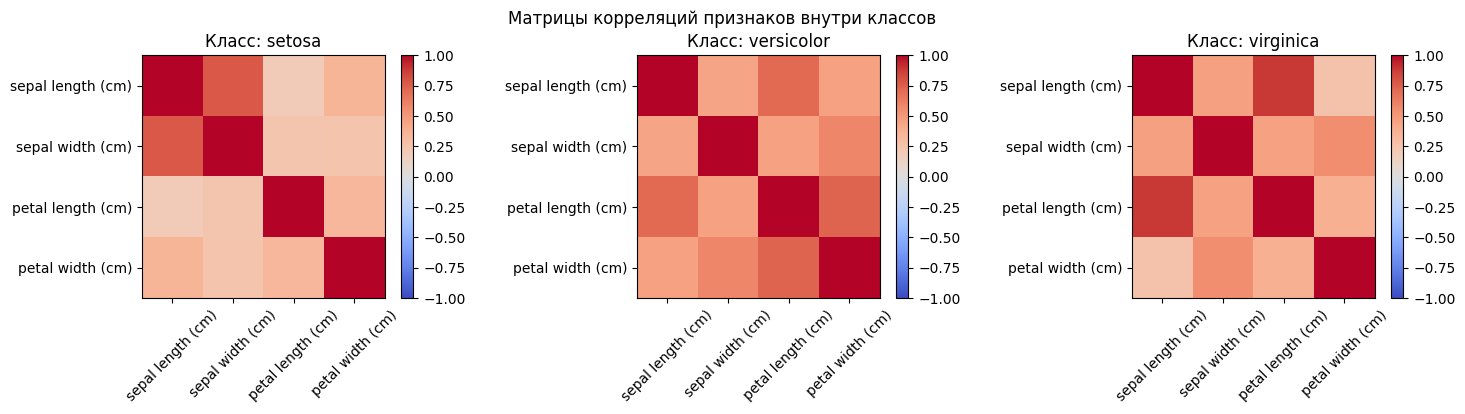

Корреляции для класса setosa:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.775,0.194,0.348
sepal width (cm),0.775,1.000,0.241,0.249
petal length (cm),0.194,0.241,1.000,0.331
petal width (cm),0.348,0.249,0.331,1.000


Корреляции для класса versicolor:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.444,0.710,0.459
sepal width (cm),0.444,1.000,0.458,0.582
petal length (cm),0.710,0.458,1.000,0.730
petal width (cm),0.459,0.582,0.730,1.000


Корреляции для класса virginica:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.466,0.890,0.265
sepal width (cm),0.466,1.000,0.461,0.551
petal length (cm),0.890,0.461,1.000,0.380
petal width (cm),0.265,0.551,0.380,1.000


In [515]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in range(3):
    X_cls = X_train[y_train == cls]
    corr = X_cls.corr()
    im = axes[cls].imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
    axes[cls].set_title(f"Класс: {data.target_names[cls]}")
    axes[cls].set_xticks(range(4))
    axes[cls].set_yticks(range(4))
    axes[cls].set_xticklabels([f for f in data.feature_names], rotation=45)
    axes[cls].set_yticklabels([f for f in data.feature_names])
    plt.colorbar(im, ax=axes[cls])

plt.suptitle("Матрицы корреляций признаков внутри классов")
plt.tight_layout()
plt.show()

print("Корреляции для класса setosa:")
display(X_train[y_train == 0].corr().round(3))
print("Корреляции для класса versicolor:")
display(X_train[y_train == 1].corr().round(3))
print("Корреляции для класса virginica:")
display(X_train[y_train == 2].corr().round(3))

Наибольшая коррелиация:

1. Setosa: sepal width - sepal lenght

2. Versicolor: petal length - sepal length, petal len - petal width, petal w - sepal w
3. Virginica: petal len - sepal len, petal width - sepal width

Это нарушает качество модели т.к. это нарушает предположение о том что признаки независимы. При том корреалирую не одни и те же а часто разные признаки.


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. В чём заключается «наивное» допущение Наивного Байеса? Почему его так называют?
2. Почему мы используем логарифм правдоподобия вместо самого правдоподобия?
3. Почему для Гауссовского Наивного Байеса стандартизация данных **не нужна**?
4. Насколько близки метрики вашей реализации к `scikit-learn`? Если есть расхождения — объясните их.
5. Посмотрите на матрицы корреляций: нарушается ли допущение о независимости признаков?
6. Когда Наивный Байес работает хорошо несмотря на нарушение допущения о независимости?
7. Сравните Наивный Байес и Логистическую регрессию: когда предпочесть один метод другому?

# ОТВЕТЫ ВЫВОДЫ ДОПЫ НИЖЕ

1. Допущение заключается в том что все признаки условно независимы(независимы для объектов 1 класса). Наивность в том что так почти не бывает тем не менее результаты вполне удовлетворительны.
2. Потому что иначе пришлось бы умножать числа меньшие единицы. Логарифм позволяет заменить умножение сложением
3. Алгоритм оценивает вероятность для каждого признака в отдельности. Ну и как бы проведя стандартизацию распределение признака от этого же не поменяется.
4. Я бы сказал идентичны
5. Да нарушается. Расписал выше
6. На небольших датасетах. и ЕСЛИ одни и те же признаки коррелируют в разных классах одинаково. если в одном коррелируют а в другом нет или коррелируют по разному то это плохо.
7. Байес - небольшой датасет, много признаков, требуется скорость. Логистическая регрессия - больше данных(хватит чтобы не переобучиться), и важны взаимосвзяи между признаками

## Дополнительные задания

### Задание A
Добавьте параметр `var_smoothing` в `MyGaussianNB` (аналог `sklearn`): добавляйте к дисперсии небольшую долю от максимальной дисперсии по всем признакам. Посмотрите, как это влияет на метрики.

### Задание B
Попробуйте применить `MyGaussianNB` к датасету `Breast Cancer` (из семинара по логистической регрессии). Сравните качество с логистической регрессией. Объясните разницу.

### Задание C
Реализуйте `predict_proba` — метод, возвращающий нормированные вероятности (не логарифмы). Для этого:
- вычислите `log_proba`,
- вычтите максимум (для численной стабильности),
- примените `exp`,
- нормируйте на сумму.

# ЗАДАНИЕ A(сюда же добавил функцию из задания C)


In [516]:
def fit_gaussian_params_vs(X, y, var_smoothing):
    classes = np.unique(y)
    n_classes = len(classes)
    n_features = X.shape[1]

    means = np.zeros((n_classes, n_features))
    variances = np.zeros((n_classes, n_features))

    for i, c in enumerate(classes):
        X_c = X[y == c]
        means[i] = np.mean(X_c, axis=0)
        variances[i] = np.var(X_c, axis=0)

    max_variance = np.max(variances)

    for i in range(n_classes):
        variances[i] = variances[i] + max_variance * var_smoothing

    return means, variances


def gaussian_log_likelihood_vs(x, mean, var):
    log_likelihood = -0.5 * np.sum(np.log(2 * np.pi * var) + (np.square((x - mean))) / var)
    return log_likelihood


class MyGaussianNB_vs:
    def __init__(self, var_smoothing = 1e-3):
        self.classes_ = None
        self.log_priors_ = None
        self.means_ = None
        self.variances_ = None
        self.var_smoothing_ = var_smoothing

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        priors = compute_priors(y)
        self.log_priors_ = np.log([priors[c] for c in self.classes_])
        self.means_, self.variances_ = fit_gaussian_params_vs(X, y, self.var_smoothing_)
        return self

    def predict_log_proba(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        log_proba = np.zeros((n_samples, n_classes))

        for i, cls in enumerate(self.classes_):
            mean = self.means_[i]
            var = self.variances_[i]
            log_prior = self.log_priors_[cls]
            for j in range(n_samples):
                log_likelihood = gaussian_log_likelihood_vs(X[j], mean, var)
                log_proba[j, i] = log_prior + log_likelihood
        return log_proba


    def predict_proba(self, X):
        log_proba = self.predict_log_proba(X)
        log_proba_max = np.max(log_proba, axis=1, keepdims=True)
        log_proba_stable = log_proba - log_proba_max
        proba = np.exp(log_proba_stable)
        proba = proba / np.sum(proba, axis=1, keepdims=True)
        return proba

    def predict(self, X):
        log_proba = self.predict_log_proba(X)
        preds = self.classes_[np.argmax(log_proba, axis=1)]
        return preds

model_var_smoothing = MyGaussianNB_vs(1e-9)
model_var_smoothing.fit(X_train_np, y_train_np)
y_pred_vs = model_var_smoothing.predict(X_test_np)

my_metrics_vs = {
    "accuracy": accuracy_score(y_test_np, y_pred_vs),
    "precision_macro": precision_score(y_test_np, y_pred_vs, average = "macro"),
    "recall_macro": recall_score(y_test_np, y_pred_vs, average = "macro"),
    "f1_macro": f1_score(y_test_np, y_pred_vs, average = "macro"),
}

pd.Series(my_metrics_vs).round(4)

,0
accuracy,0.9667
precision_macro,0.9697
recall_macro,0.9667
f1_macro,0.9666


Добавио smoothing. для этого переписал функцию fit_gaussian_params сделав нахождение максмиальной дисперсии по всем признакам и прибавление к определенной дисперсии указанной величины.

Переписал gaussian_log_likelihood убрав оттуда прибавление малой величины для защиты делания на ноль.

Вообще эффект влияния на метрики не заметен. Ибо максимальная дисперсия если смотреть ячейки выше была 0.46.. Таким образом все мои действия в двух функциях грубо говоря себя скомпенсировали. Ну и в целом эффект от столь малых значений мал. Если var_smoothing параметр сделать примерно 0.5 или 1 или выше то метрики начинают падать драматически.

# Задание B

In [517]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
nb_model_cancer = MyGaussianNB()

nb_model_cancer.fit(X_train_cancer.values, y_train_cancer.values)
cancer_y_pred = nb_model_cancer.predict(X_test_cancer.values)

cancer_metrics = {
    "accuracy": accuracy_score(y_test_cancer.values, cancer_y_pred),
    "precision": precision_score(y_test_cancer.values, cancer_y_pred),
    "recall": recall_score(y_test_cancer.values, cancer_y_pred),
    "f1": f1_score(y_test_cancer.values, cancer_y_pred),
}

pd.Series(cancer_metrics).round(4)

,0
accuracy,0.9298
precision,0.9444
recall,0.9444
f1,0.9444


Результат хуже чем у логистической регресии. Надо посмотреть на данные. Помню что был дисбаланс классов(сейчас ниже убедимся) и думаю стоит проверить по матрице коррелиаций взаимную коррелиацию признаков


In [518]:
priors_cancer = compute_priors(y_train_cancer.values)
print("Априорные вероятности:", priors_cancer)
print("Сумма:", sum(priors_cancer.values()))

Априорные вероятности: {np.int64(0): np.float64(0.37362637362637363), np.int64(1): np.float64(0.6263736263736264)}
Сумма: 1.0


Присутствует легкий дисбаланс. миноритарный класс составлет 37 процентов.

матрица коррелиаций:

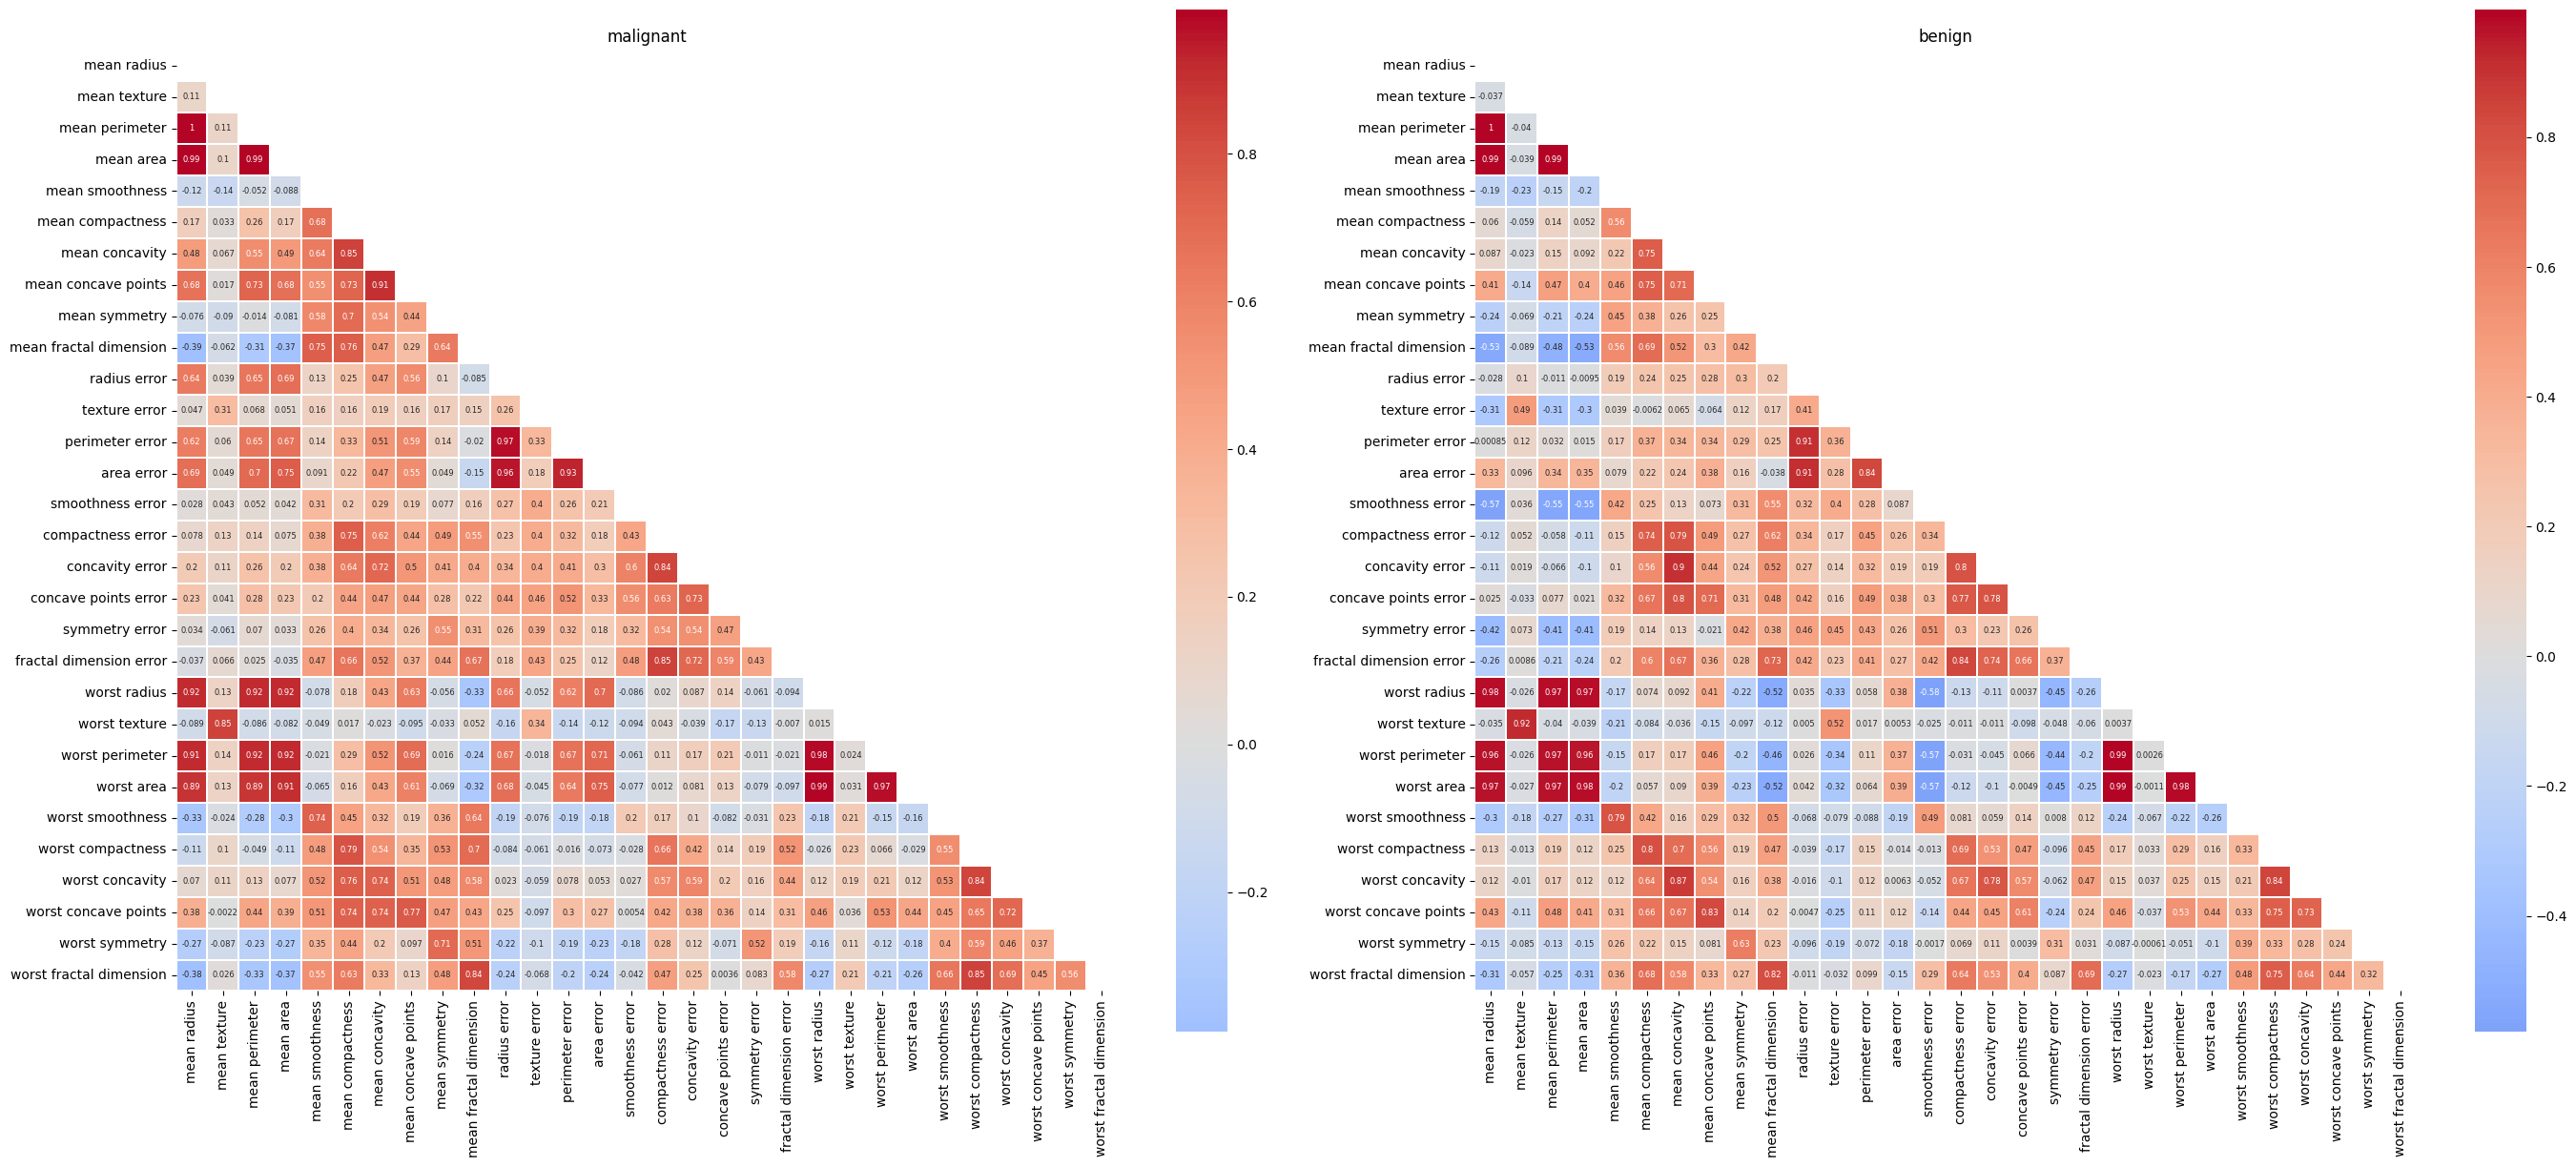

In [519]:
# Матрица корреляций
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(28, 14))

for i in range(2):
    x_class = X[y == i]
    sns.heatmap(x_class.corr(), mask = mask,annot=True, cmap="coolwarm",
                center=0, square=True, linewidths=0.1,
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 6}, ax=axes[i])
    axes[i].set_title(f"{data.target_names[i]}")

plt.tight_layout()
plt.show()

Можем наблюдать высокую мультиколлинеарность. часть признаков коррелируют(именно бордовые) в разных классах одинаково и это частично исправляет ситуацию(ошибка сокращается). Но слева в целом видны более персиково-оранжевые зоны.(справа бледнее). Всё это противоречит положению наивного байеса о том что признаки независимы внутри классов. потому результат похуже чем у логической регресии.

Для логрегрессии метрика pecision равнялась 0.9867

Наивный байес выдал 0.9444

In [520]:
means, variances = fit_gaussian_params(X_train_cancer, y_train_cancer.values)
print("\nМатрица дисперсий (признак x класс):")
df_variances = pd.DataFrame(variances.T, index=data.feature_names, columns=data.target_names)
display(df_variances.round(4))


Матрица дисперсий (признак x класс):


,malignant,benign
mean radius,9.9609,3.1067
mean texture,15.4121,16.5401
mean perimeter,464.8810,135.9031
mean area,126504.7062,17616.1895
mean smoothness,0.0002,0.0002
mean compactness,0.0030,0.0011
mean concavity,0.0058,0.0021
mean concave points,0.0012,0.0002
mean symmetry,0.0008,0.0006
mean fractal dimension,0.0001,0.0000


есть признаки с очень низкой дисперсией. и есть признаки с очень высокой дисперсией. признаки с малой дисперсией будут доминировать.

# Задание C

применим метод для новой модели. видим нормированные вероятности

In [521]:
model = MyGaussianNB_vs(1e-9)
model.fit(X_train_np, y_train_np)
y_pred = model.predict(X_test_np)
proba_pred = model.predict_proba(X_test_np)
print("Predicted - Real - Proba_pred")

for i in range(len(X_test_np)):
    print(f"{y_pred[i]} - {y_test_np[i]} - {proba_pred[i].round(3)}")

Predicted - Real - Proba_pred
0 - 0 - [1. 0. 0.]
2 - 2 - [0.    0.088 0.912]
1 - 1 - [0. 1. 0.]
1 - 1 - [0. 1. 0.]
0 - 0 - [1. 0. 0.]
1 - 1 - [0.    0.648 0.352]
0 - 0 - [1. 0. 0.]
0 - 0 - [1. 0. 0.]
2 - 2 - [0. 0. 1.]
1 - 1 - [0.    0.993 0.007]
2 - 2 - [0. 0. 1.]
2 - 2 - [0. 0. 1.]
2 - 2 - [0. 0. 1.]
1 - 1 - [0.    0.954 0.046]
0 - 0 - [1. 0. 0.]
0 - 0 - [1. 0. 0.]
0 - 0 - [1. 0. 0.]
1 - 1 - [0. 1. 0.]
1 - 1 - [0.    0.991 0.009]
2 - 2 - [0.    0.164 0.836]
0 - 0 - [1. 0. 0.]
2 - 2 - [0. 0. 1.]
1 - 1 - [0.    0.994 0.006]
2 - 2 - [0.    0.472 0.528]
2 - 2 - [0. 0. 1.]
2 - 1 - [0.    0.059 0.941]
1 - 1 - [0.    0.991 0.009]
0 - 0 - [1. 0. 0.]
2 - 2 - [0.    0.001 0.999]
0 - 0 - [1. 0. 0.]


Можно кстати видеть единственную ошибку. При том модель ошиблась с большой уверенностью: 2 - 1 - [0.    0.059 0.941]

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- оценка параметров Гауссовского Наивного Байеса с нуля;
- классификация по правилу Байеса;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ допущения о независимости;
- выводы.

Не сдавайте ноутбук без текстовых выводов.